In [ ]:
!pip install transformers datasets scikit-learn torch streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.1 MB/s eta 0:00:00


Import Libraries and Load Data

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Define labels in exact order
LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# Load dataset
df = pd.read_csv("/content/train_data.csv")


# Only keep text + labels
df = df[["comment_text"] + LABELS]

# Split features and labels
X = df["comment_text"].values
y = df[LABELS].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Tokenization (Toxic-BERT)

In [28]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("unitary/toxic-bert")

# Tokenize text
def tokenize_texts(texts, max_length=128):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

train_encodings = tokenize_texts(X_train)
test_encodings = tokenize_texts(X_test)

Create Dataset for PyTorch

In [29]:
import torch

class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}, self.labels[idx]

train_dataset = ToxicDataset(train_encodings, y_train)
test_dataset = ToxicDataset(test_encodings, y_test)

Load Toxic-BERT Model

In [30]:

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "unitary/toxic-bert",
    num_labels=len(LABELS),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training Setup

In [31]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Loss
criterion = BCEWithLogitsLoss()

Training Loop

In [32]:
import torch

# Take a tiny subset for demo
X_train_small = X_train[:100]
y_train_small = y_train[:100]

# Re-tokenize the tiny subset
train_encodings_small = tokenizer(list(X_train_small), padding=True, truncation=True, max_length=64, return_tensors="pt")

# Tiny dataset
class TinyToxicDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}, self.labels[idx]

train_dataset_small = TinyToxicDataset(train_encodings_small, y_train_small)

# DataLoader
train_loader_small = torch.utils.data.DataLoader(train_dataset_small, batch_size=8, shuffle=True)

# Optimizer & loss
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.BCEWithLogitsLoss()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Fine-tune 1–2 epochs on tiny dataset
for epoch in range(2):
    model.train()
    for batch in train_loader_small:
        inputs, labels = batch
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(**inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Tiny fine-tune epoch {epoch+1} completed")

print("Demo fine-tuning done!")

Tiny fine-tune epoch 1 completed
Tiny fine-tune epoch 2 completed
Demo fine-tuning done!


Evaluation Metrics

In [33]:
X_test_small = X_test[:1000]
y_test_small = y_test[:1000]

# Re-tokenize
test_encodings_small = tokenizer(list(X_test_small), padding=True, truncation=True, max_length=64, return_tensors="pt")
test_dataset_small = ToxicDataset(test_encodings_small, y_test_small)
test_loader_small = torch.utils.data.DataLoader(test_dataset_small, batch_size=32)

# Evaluation loop
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader_small:
        inputs, labels = batch
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        outputs = model(**inputs).logits
        preds = torch.sigmoid(outputs).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

import numpy as np
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
all_preds_bin = (all_preds >= 0.5).astype(int)

from sklearn.metrics import f1_score
print("Micro F1:", f1_score(all_labels, all_preds_bin, average="micro"))
print("Macro F1:", f1_score(all_labels, all_preds_bin, average="macro"))

Micro F1: 0.460431654676259
Macro F1: 0.3734038563100656


Save Model

In [34]:
model.save_pretrained("/content/toxic-bert-model")
tokenizer.save_pretrained("/content/toxic-bert-tokenizer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/toxic-bert-tokenizer/tokenizer_config.json',
 '/content/toxic-bert-tokenizer/tokenizer.json')

accuracy precision scores


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Subset Accuracy (exact match across all labels)
subset_acc = accuracy_score(all_labels, all_preds_bin)
print(" Accuracy (all labels match):", subset_acc)

# Micro metrics (aggregate over all labels)
micro_prec = precision_score(all_labels, all_preds_bin, average="micro")
micro_rec = recall_score(all_labels, all_preds_bin, average="micro")
print("Micro Precision:", micro_prec)
print("Micro Recall:", micro_rec)

# Macro metrics (average across labels)
macro_prec = precision_score(all_labels, all_preds_bin, average="macro")
macro_rec = recall_score(all_labels, all_preds_bin, average="macro")
print("Macro Precision:", macro_prec)
print("Macro Recall:", macro_rec)

# Per-label metrics (classification report)
labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
report = classification_report(all_labels, all_preds_bin, target_names=labels)
print("\nPer-label Metrics:\n", report)

 Accuracy (all labels match): 0.911
Micro Precision: 0.8648648648648649
Micro Recall: 0.3137254901960784
Macro Precision: 0.7529644268774703
Macro Recall: 0.26042792412473265

Per-label Metrics:
                precision    recall  f1-score   support

        toxic       1.00      0.40      0.57        96
 severe_toxic       0.00      0.00      0.00         7
      obscene       0.91      0.21      0.34        47
       threat       1.00      0.50      0.67         2
       insult       0.61      0.31      0.41        45
identity_hate       1.00      0.14      0.25         7

    micro avg       0.86      0.31      0.46       204
    macro avg       0.75      0.26      0.37       204
 weighted avg       0.86      0.31      0.45       204
  samples avg       0.03      0.03      0.03       204



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [36]:
pip install matplotlib

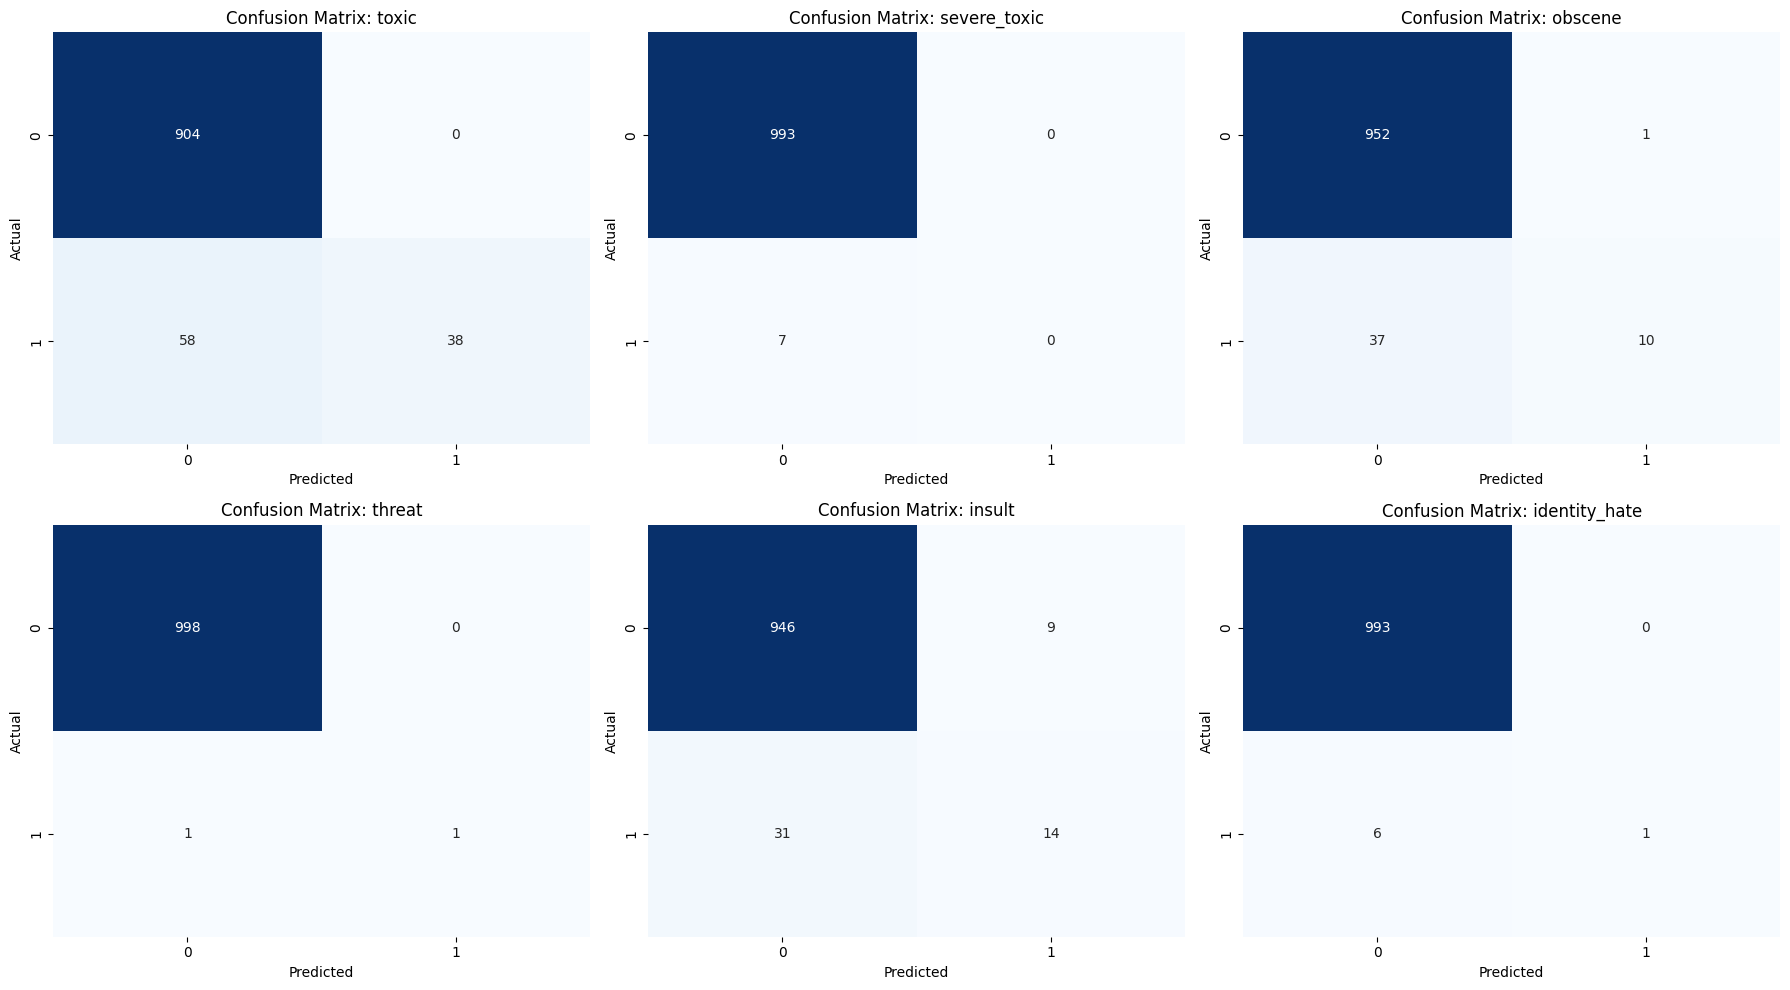

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

plt.figure(figsize=(18, 10))

for i, label in enumerate(labels):
    cm = confusion_matrix(all_labels[:, i], all_preds_bin[:, i])
    plt.subplot(2, 3, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


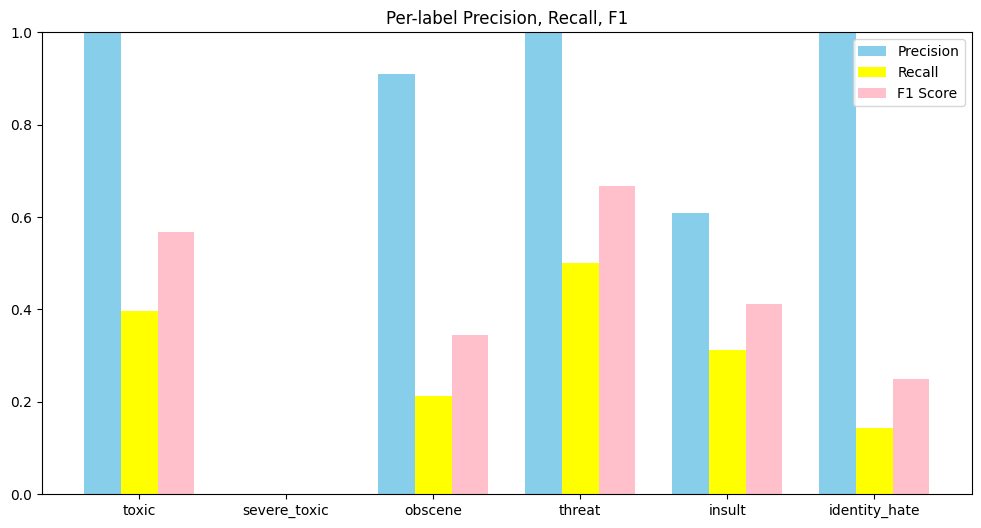

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Calculate per-label metrics
precisions = precision_score(all_labels, all_preds_bin, average=None)
recalls = recall_score(all_labels, all_preds_bin, average=None)
f1s = f1_score(all_labels, all_preds_bin, average=None)

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, precisions, width, label='Precision', color='skyblue')
plt.bar(x, recalls, width, label='Recall', color='yellow')
plt.bar(x + width, f1s, width, label='F1 Score', color='pink')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.title("Per-label Precision, Recall, F1")
plt.legend()
plt.show()

/tmp/ipykernel_389/1958292696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=pred_sums, palette="viridis")


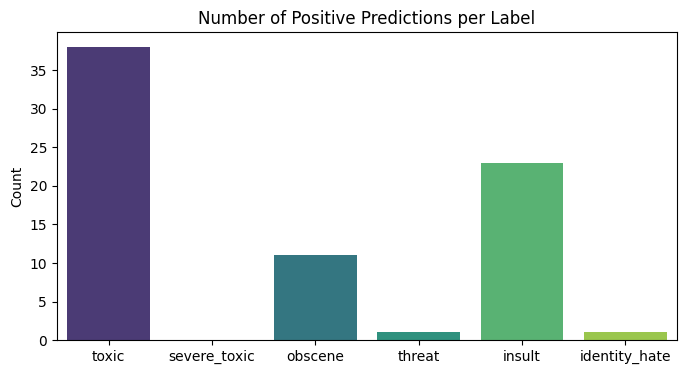

In [39]:
pred_sums = all_preds_bin.sum(axis=0)
plt.figure(figsize=(8,4))
sns.barplot(x=labels, y=pred_sums, palette="viridis")
plt.title("Number of Positive Predictions per Label")
plt.ylabel("Count")
plt.show()

In [ ]:
# """%%writefile app.py
# import streamlit as st
# import torch
# import numpy as np
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# # Define labels in exact order
# LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# # Load tokenizer and model
# tokenizer = AutoTokenizer.from_pretrained("/content/toxic-bert-tokenizer")
# model = AutoModelForSequenceClassification.from_pretrained("/content/toxic-bert-model")

# # Set model to evaluation mode
# model.eval()

# print("Streamlit app script 'app.py' created successfully.")"""

In [ ]:
# %%writefile -a app.py

# def predict(text):
#     # Tokenize input text
#     inputs = tokenizer(
#         text,
#         padding=True,
#         truncation=True,
#         max_length=128,
#         return_tensors="pt"
#     )

#     # Move inputs to same device as model
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.to(device)
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     # Perform inference
#     with torch.no_grad():
#         outputs = model(**inputs)
#         logits = outputs.logits

#     # Apply sigmoid to get probabilities
#     probs = torch.sigmoid(logits).cpu().numpy()[0]

#     return probs

# print("Prediction function 'predict' appended to 'app.py'.")

In [ ]:
# !npm install -g localtunnel

In [ ]:
# import urllib
# print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

In [ ]:
# !streamlit run app.py & npx localtunnel --port 8501

In [ ]:
# %%writefile -a app.py

# import pandas as pd

# # Streamlit UI
# st.title("Toxic Comment Classifier")
# st.write("Enter a comment below to analyze its toxicity levels across multiple categories.")

# # User input
# user_input = st.text_area("Comment Text", placeholder="Type something here...")

# if st.button("Classify"):
#     if user_input.strip() == "":
#         st.warning("Please enter some text to classify.")
#     else:
#         with st.spinner("Analyzing..."):
#             # Get predictions
#             probabilities = predict(user_input)

#             # Create a dictionary for mapping
#             results = {label: float(prob) for label, prob in zip(LABELS, probabilities)}

#             # Display results as a bar chart
#             st.subheader("Toxicity Probabilities")
#             chart_data = pd.DataFrame(list(results.items()), columns=['Category', 'Probability'])
#             st.bar_chart(chart_data.set_index('Category'))

#             # Display results as descriptive text
#             for label, prob in results.items():
#                 st.write(f"**{label.replace('_', ' ').title()}**: {prob:.4f}")

# print("Streamlit UI components appended to 'app.py'.")

In [26]:
import shutil

shutil.make_archive("toxic_model", 'zip', "/content/toxic-bert-model")
shutil.make_archive("toxic_tokenizer", 'zip', "/content/toxic-bert-tokenizer")

'/content/toxic_tokenizer.zip'